In [1]:
import os

dataset_path = "/kaggle/input/datasets/sunillimbu10/hagrid-classification/hagrid-classification"

classes = sorted([c for c in os.listdir(dataset_path)
                  if os.path.isdir(os.path.join(dataset_path, c))])

print(f"Dataset Summary:")
print(f"{'='*40}")
total = 0
for cls in classes:
    count = len([f for f in os.listdir(os.path.join(dataset_path, cls))
                 if f.lower().endswith(('.jpg', '.jpeg', '.png'))])
    total += count
    print(f"  {cls:<12}: {count:>6} images")
print(f"{'='*40}")
print(f"  {'TOTAL':<12}: {total:>6} images")
print(f"  {'CLASSES':<12}: {len(classes)}")

Dataset Summary:
  call        :  15000 images
  dislike     :  15000 images
  fist        :  15000 images
  like        :  15000 images
  mute        :  15000 images
  ok          :  15000 images
  stop        :  15000 images
  TOTAL       : 105000 images
  CLASSES     : 7


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets
import matplotlib.pyplot as plt

print(f"PyTorch: {torch.__version__}")
print(f"GPU available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.10.0+cu128
GPU available: True
GPU: Tesla T4


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
# Create a transforms for train and val
from torchvision import transforms,datasets 
train_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transforms=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

In [5]:
# Split the dataset into train, test and val
from sklearn.model_selection import train_test_split

full_dataset = datasets.ImageFolder(dataset_path)

indices = list(range(len(full_dataset)))
labels  = [full_dataset.targets[i] for i in indices]

train_idx, temp_idx = train_test_split(
    indices, test_size=0.2, stratify=labels, random_state=42
)

temp_labels = [labels[i] for i in temp_idx]

val_idx, test_idx = train_test_split(
    temp_idx, test_size=0.5, stratify=temp_labels, random_state=42
)

print(f"Train: {len(train_idx)}")
print(f"Val  : {len(val_idx)}")
print(f"Test : {len(test_idx)}")

Train: 84000
Val  : 10500
Test : 10500


In [6]:
from torch.utils.data import Subset

# Apply transforms
train_dataset = Subset(datasets.ImageFolder(dataset_path, transform=train_transforms), train_idx)
val_dataset   = Subset(datasets.ImageFolder(dataset_path, transform=val_transforms),   val_idx)
test_dataset  = Subset(datasets.ImageFolder(dataset_path, transform=val_transforms),   test_idx)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,  num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=64, shuffle=False, num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=64, shuffle=False, num_workers=4, pin_memory=True)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")

Train batches : 1313
Val batches   : 165
Test batches  : 165


In [7]:
!pip install timm -q

In [8]:
import timm
model=timm.create_model("efficientnet_b0", pretrained=True, num_classes=7)
model=model.to(device)

model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [9]:
model

EfficientNet(
  (conv_stem): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
  (bn1): BatchNormAct2d(
    32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
    (drop): Identity()
    (act): SiLU(inplace=True)
  )
  (blocks): Sequential(
    (0): Sequential(
      (0): DepthwiseSeparableConv(
        (conv_dw): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
        (bn1): BatchNormAct2d(
          32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True
          (drop): Identity()
          (act): SiLU(inplace=True)
        )
        (aa): Identity()
        (se): SqueezeExcite(
          (conv_reduce): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
          (act1): SiLU(inplace=True)
          (conv_expand): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
          (gate): Sigmoid()
        )
        (conv_pw): Conv2d(32, 16, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (bn2

In [10]:
# Freez features 
for param in model.parameters():
    param.requires_grad = False

for param in model.get_classifier().parameters():
    param.requires_grad = True

In [11]:
from torch.cuda.amp import GradScaler, autocast
lr=1e-3 
epochs=20
scaler = torch.amp.GradScaler('cuda') # faster
criterion = nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(model.parameters(),lr=lr)

In [12]:
# Training Function
def train_one_epoch(model, loader, optimizer, criterion, scaler, device):
    model.train()
    
    total_loss = 0
    correct=  0
    total =  0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()

        with torch.amp.autocast('cuda'):
            outputs = model(images)
            loss    = criterion(outputs, labels)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)

    return total_loss / len(loader), correct / total


def validate(model, loader, criterion, device):
    model.eval()
    total_loss= 0
    correct= 0 
    total = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                outputs = model(images)
                loss    = criterion(outputs, labels)

            total_loss += loss.item()
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += labels.size(0)

    return total_loss / len(loader), correct / total

In [13]:
best_val_acc   = 0.0
patience_count = 0
history        = {"train_loss": [], "val_loss": [],
                  "train_acc" : [], "val_acc" : []}
# phase 1 training 
for epoch in range(5):
    tr_loss, tr_acc = train_one_epoch(model, train_loader,optimizer, criterion,scaler, device)
    vl_loss, vl_acc = validate(model, val_loader,criterion, device)

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"Epoch [{epoch+1}/5] "
          f"Train Loss: {tr_loss:.4f} Accuracy: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Accuracy: {vl_acc:.4f}")

Epoch [1/5] Train Loss: 0.8192 Accuracy: 0.7384 | Val Loss: 0.4167 Accuracy: 0.8585
Epoch [2/5] Train Loss: 0.3531 Accuracy: 0.8795 | Val Loss: 0.3047 Accuracy: 0.8955
Epoch [3/5] Train Loss: 0.2895 Accuracy: 0.9001 | Val Loss: 0.2702 Accuracy: 0.9077
Epoch [4/5] Train Loss: 0.2616 Accuracy: 0.9090 | Val Loss: 0.2468 Accuracy: 0.9142
Epoch [5/5] Train Loss: 0.2402 Accuracy: 0.9161 | Val Loss: 0.2386 Accuracy: 0.9188


In [14]:
# phase 2 training all parameters
fine_tune_lr = 1e-4
patience     = 5
for param in model.parameters():
    param.requires_grad = True

optimizer = torch.optim.AdamW(model.parameters(), lr=fine_tune_lr)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)



for epoch in range(epochs):
    tr_loss, tr_acc = train_one_epoch(
        model, train_loader, optimizer, criterion, scaler, device)
    vl_loss, vl_acc = validate(
        model, val_loader, criterion, device)
    
    scheduler.step()

    history["train_loss"].append(tr_loss)
    history["val_loss"].append(vl_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(vl_acc)

    print(f"  Epoch [{epoch+1}/{epochs}] "
          f"Train Loss: {tr_loss:.4f} Accuracy: {tr_acc:.4f} | "
          f"Val Loss: {vl_loss:.4f} Accuracy: {vl_acc:.4f}")

    # Save best model
    if vl_acc > best_val_acc:
        best_val_acc = vl_acc
        torch.save({
            "model_state": model.state_dict(),
            "classes"    : classes,
            "val_acc"    : vl_acc
        }, "/kaggle/working/best_model.pth")
        print(f"Saved! Val Acc: {vl_acc:.4f}")

    # Early stopping
    else:
        patience_count += 1
        if patience_count >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

print(f"\n Done! Best Val Accuracy: {best_val_acc:.4f}")

  Epoch [1/20] Train Loss: 0.0380 Accuracy: 0.9880 | Val Loss: 0.0111 Accuracy: 0.9965
Saved! Val Acc: 0.9965
  Epoch [2/20] Train Loss: 0.0112 Accuracy: 0.9963 | Val Loss: 0.0096 Accuracy: 0.9973
Saved! Val Acc: 0.9973
  Epoch [3/20] Train Loss: 0.0074 Accuracy: 0.9974 | Val Loss: 0.0077 Accuracy: 0.9978
Saved! Val Acc: 0.9978
  Epoch [4/20] Train Loss: 0.0050 Accuracy: 0.9983 | Val Loss: 0.0108 Accuracy: 0.9971
  Epoch [5/20] Train Loss: 0.0046 Accuracy: 0.9985 | Val Loss: 0.0133 Accuracy: 0.9967
  Epoch [6/20] Train Loss: 0.0035 Accuracy: 0.9988 | Val Loss: 0.0103 Accuracy: 0.9968
  Epoch [7/20] Train Loss: 0.0033 Accuracy: 0.9990 | Val Loss: 0.0086 Accuracy: 0.9977
  Epoch [8/20] Train Loss: 0.0019 Accuracy: 0.9993 | Val Loss: 0.0133 Accuracy: 0.9970

Early stopping at epoch 8

 Done! Best Val Accuracy: 0.9978


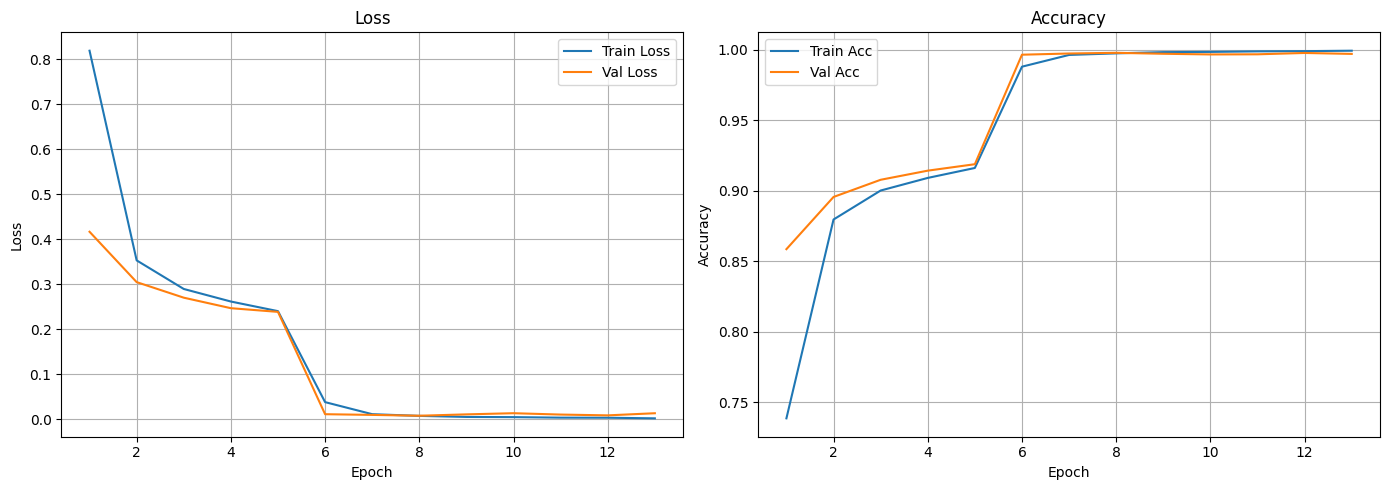

In [16]:
import matplotlib.pyplot as plt

epochs_range = range(1, len(history["train_loss"]) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss plot
ax1.plot(epochs_range, history["train_loss"], label="Train Loss")
ax1.plot(epochs_range, history["val_loss"],   label="Val Loss")
ax1.set_title("Loss")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True)

# Accuracy plot
ax2.plot(epochs_range, history["train_acc"], label="Train Acc")
ax2.plot(epochs_range, history["val_acc"],   label="Val Acc")
ax2.set_title("Accuracy")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy")
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig("/kaggle/working/training_plot.png")
plt.show()

Test Accuracy: 99.64761904761905%

 Classification Report:
              precision    recall  f1-score   support

        call       1.00      0.99      0.99      1500
     dislike       1.00      1.00      1.00      1500
        fist       1.00      1.00      1.00      1500
        like       0.99      0.99      0.99      1500
        mute       1.00      0.99      0.99      1500
          ok       1.00      1.00      1.00      1500
        stop       1.00      1.00      1.00      1500

    accuracy                           1.00     10500
   macro avg       1.00      1.00      1.00     10500
weighted avg       1.00      1.00      1.00     10500



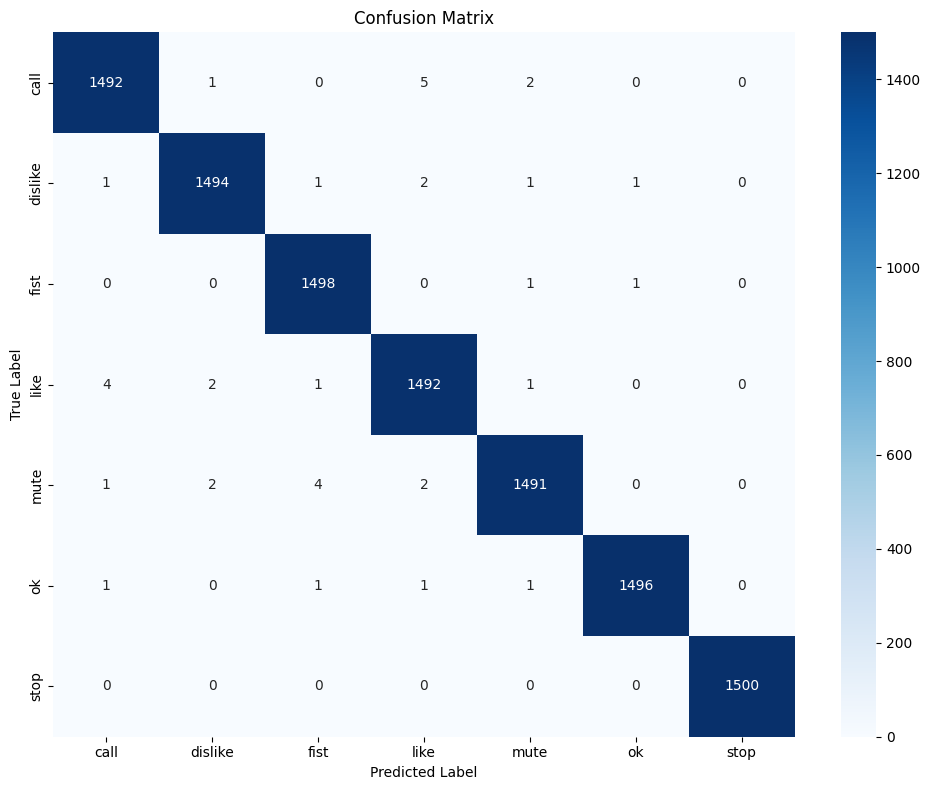

In [20]:
# Metrices
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import numpy as np

model.eval()
correct=0
total=0
all_preds  = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds   = outputs.argmax(1)
        correct+=(preds==labels).sum().item()
        total   += labels.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Test accuracy
print(f"Test Accuracy: {(correct/total)*100}%")

# Classification report
print("\n Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=classes,
            yticklabels=classes,
            cmap="Blues")
plt.title("Confusion Matrix")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.savefig("/kaggle/working/confusion_matrix.png")
plt.show()